# Binary orbit

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import GaiaAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.results import SamplingResults
from exogaia.samplers import MCMCSampler, NestedSampler

## Gaia epoch astrometry

The ``GaiaAstrometry`` class is used for storing Gaia epoch astrometry. For now, we can simulate epoch astrometry for Gaia DR4 or DR5. To do so, we can either set the stellar parameters manually or retrieve parameters from DR3.

In this example, we simulate a binary system by manually providing the stellar parameters. We choose a relatively small orbit such that most of the phase is well sampled by the simulated measurements.

In [3]:
primary_mass = (1.0, 0.1)  # (Msun)
mass_2 = 0.01  # (Msun)
flux_ratio = 0.0

In [4]:
epoch_astrom = GaiaAstrometry(primary_mass=primary_mass, gaia_release='DR4')


Gaia astrometry

Gaia release: DR4
Reference epoch: J2017.500

Primary mass (Msun): 1.00 +/- 0.10


In [5]:
model_param = {
    'ra_ref': 15.0,
    'dec_ref': -40.0,
    'ra_offset': -5.0,
    'dec_offset': 2.0,
    'parallax': 10.0,
    'pm_ra': -30.0,
    'pm_dec': 30.0,
    'g_mag': 7.0,
    'ecc': 0.3,
    'tau': 0.5,
    'inc': np.radians(60.),
    'aop': np.radians(40.),
    'pan': np.radians(90.),
    'sma': 2.,
}

In [6]:
model_param = epoch_astrom.simulate_data(
    model_param=model_param,
    mass_2=mass_2,
    flux_ratio=flux_ratio,
    occ_rate=None,
    sigma_per_ccd=None,
    csv_out=None,
    seed=1,
    reject_fraction=False,
)


-------------
Simulate data
-------------

System type: binary

Primary mass (Msun): 1.00 +/- 0.10

AL scan uncertainty (per CCD) = 159.98 uas
AL scan uncertainty (per transit) = 56.56 uas

Additional parameters:
   - Primary mass (Msun) = 1.00
   - Companion mass (Msun) = 1.00e-02
   - Mass ratio = 1.00e-02
   - Flux ratio = 0.00e+00
   - Relative semi-major axis (au) = 2.00

Star model

Epoch astrometry: GaiaAstrometry

-----------------------
Calculate stellar track
-----------------------

Stellar parameters:
   - RA offset (mas) = -5.000
   - Dec offset (mas) = 2.000
   - Parallax (mas) = 10.000
   - Proper motion in RA (mas/yr) = -30.000
   - Proper motion in Dec (mas/yr) = 30.000

Kepler model

Epoch astrometry: GaiaAstrometry

---------------------
Calculate orbit model
---------------------

Orbit parameters:
   - Period (days) = 1027.956
   - Eccentricity = 0.300
   - Relative time of periastron = 0.500
   - Semi-major axis (mas) = 20.000
   - Inclination (deg) = 60.000
   -

## Infer parameters with least-squares

In [7]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Orbit grid (12-parameters)
--------------------------



  0%|          | 0/900 [00:00<?, ?it/s]


Best-fit RUWE = 1.189

Best-fit stellar track:
   - RA offset (mas) = -4.992 +/- 0.009
   - Dec offset (mas) = 1.971 +/- 0.010
   - Parallax (mas) = 9.993 +/- 0.012
   - mu in RA (mas/yr) = -30.012 +/- 0.005
   - mu in Dec (mas/yr) = 30.006 +/- 0.005

Best-fit orbit:
   - Period (days) = 893.480
   - Eccentricity = 0.167
   - Relative time of periastron = 0.37
   - Thiele-Innes A = 0.009 +/- 0.011
   - Thiele-Innes B = -0.161 +/- 0.011
   - Thiele-Innes F = 0.079 +/- 0.013
   - Thiele-Innes G = -0.004 +/- 0.012

Derived parameters:
   - Semi-major axis of photocenter (mas) = 0.162 +/- 0.011
   - Relative semi-major axis (au) = 1.821
   - Mass function (Msun) = 7.067e-07
   - Companion mass (Msun) = 8.960e-03

Conversion to Campbell elements:
   - Period = 893.480 days
   - Eccentricity = 0.167
   - Relative time of periastron = 0.367
   - Semi-major axis of photocenter (mas) = 0.162
   - Inclination (deg) = 60.833
   - Argument of periastron (deg) = 175.829
   - PA of ascending node (

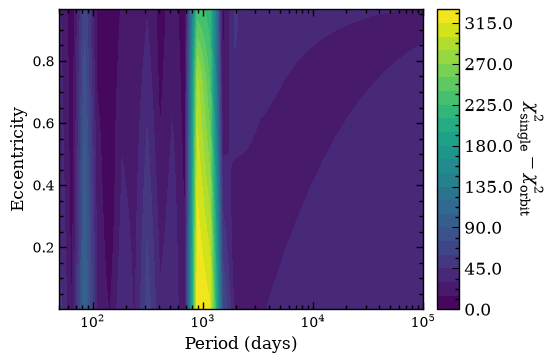

In [8]:
fig = leastsq.orbit_grid(map_type='chi2_det', n_sigma=[3], plot_file='plot.png', n_points=30)


-------------------------
Orbit fit (12 parameters)
-------------------------

Reduced chi^2: 0.964
RUWE: 0.982

Best-fit stellar track:
   - RA offset (mas) = -5.018 +/- 0.028
   - Dec offset (mas) = 1.979 +/- 0.022
   - Parallax (mas) = 9.987 +/- 0.012
   - mu in RA (mas/yr) = -30.002 +/- 0.005
   - mu in Dec (mas/yr) = 29.997 +/- 0.005

Best-fit orbit:
   - Period (days) = 1002.578 +/- 16.110
   - Eccentricity = 0.294 +/- 0.104
   - Relative time of periastron = 0.434 +/- 0.063
   - Semi-major axis of photocenter (mas) = 0.183 +/- 0.010
   - Inclination (deg) = 56.936 +/- 5.762
   - Argument of periastron (deg) = 193.048 +/- 27.597
   - PA of ascending node (deg) = 95.430 +/- 5.709

Number of function evaluations: 11
Number of Jacobian evaluations: 11

Derived parameters:
   - Relative semi-major axis (au) = 1.967
   - Mass function (Msun) = 8.170e-07
   - Companion mass (Msun) = 9.407e-03


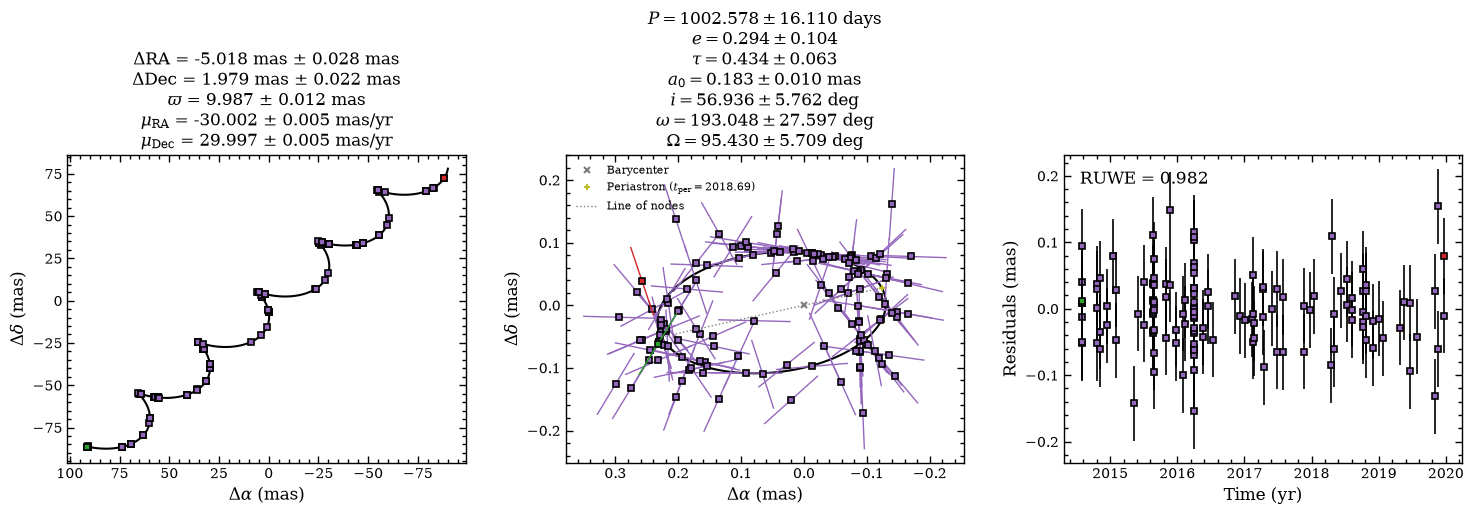

In [9]:
fig = leastsq.orbit_fit(inc_jitter=False, plot_file='plot.png')

In [10]:
print(leastsq)

LeastSquares(Δα = -5.01829 mas, Δδ = 1.97936 mas, ϖ = 9.98696 mas, μ_α = -30.0017 mas/yr, μ_δ = 29.9973 mas/yr, P = 1002.58 days, e = 0.294091, τ = 0.433948, a = 0.183034 mas, i = 0.993716 rad, ω = 3.36932 rad, Ω = 1.66557 rad)


## Infer parameters with MCMC

In [11]:
sampler = MCMCSampler(epoch_astrometry=epoch_astrom, least_squares=leastsq)
# sampler = NestedSampler(epoch_astrometry=epoch_astrom, least_squares=leastsq)


MCMC sampler

Primary mass (Msun) = 1.00 +/- 0.10
Number of parameters: 12

Priors:
   - ra_offset -> Normal: [-5.02, 0.10]
   - dec_offset -> Normal: [1.98, 0.10]
   - parallax -> Normal: [9.99, 0.10]
   - pmra -> Normal: [-30.00, 0.10]
   - pmdec -> Normal: [30.00, 0.10]
   - per -> Normal: [1002.58, 16.11]
   - ecc -> Normal: [0.29, 0.10]
   - tau -> Normal: [0.43, 0.06]
   - sma -> Normal: [0.18, 0.01]
   - inc -> Normal: [0.99, 0.10]
   - aop -> Normal: [3.37, 0.48]
   - pan -> Normal: [1.67, 0.10]


In [12]:
sampler.run_ptmcmc(
    pickle_file='exogaia.pkl',
    n_temps=10,
    n_walkers=200,
    n_steps=1000,
    n_sweeps=1,
    progress=True,
)


-------------
Run reddemcee
-------------



100%|███████████████████████████████████████████████████████| 10000/10000 [07:09<00:00, 23.28it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [57.24663485 59.91063836 54.9500657  46.32385269 51.04602256 60.15468037
 60.83090011 65.03173915 60.42616765 61.29915746 64.32829237 59.21184225]
The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [60.99900717 59.59990123 56.45037231 49.697147   52.10935717 60.5270045
 60.79744084 64.97710508 63.91256259 63.35066489 65.44470612 61.26290827]
The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [64.99954048 65.27613753 61.65863846 58.34920733 57.94168333 62.60360669
 64.53774598 61.14748418 58.78204181 59.738371

## Plot sampling results

In [13]:
results = SamplingResults(burnin=500, pickle_file='exogaia.pkl')


Fit results

Number of parameters: 12
Samples shape: (10, 1000, 200, 12)

Burnin: 500
Samples shape: (10, 500, 200, 12)

Reshaped samples: (1000000, 12)



------------
Plot walkers
------------

Number of walkers: 100
Thin value: 1


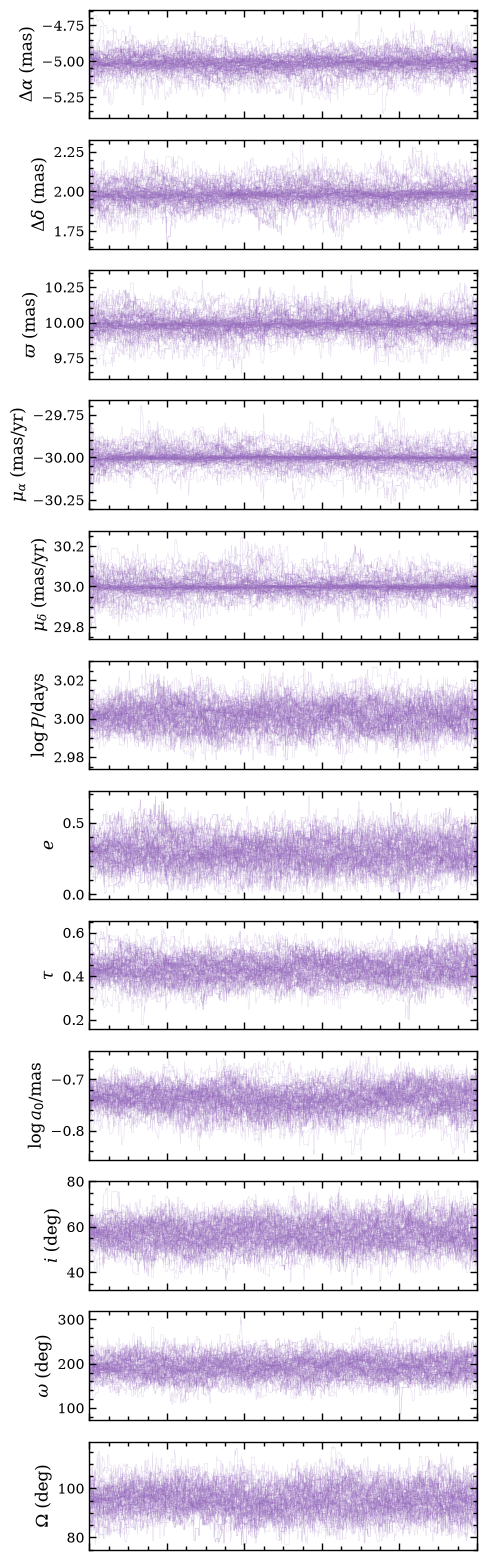

In [14]:
fig = results.plot_walkers(n_walkers=100, thin=None, plot_file=None)


--------------
Plot posterior
--------------

Output file: plot.png


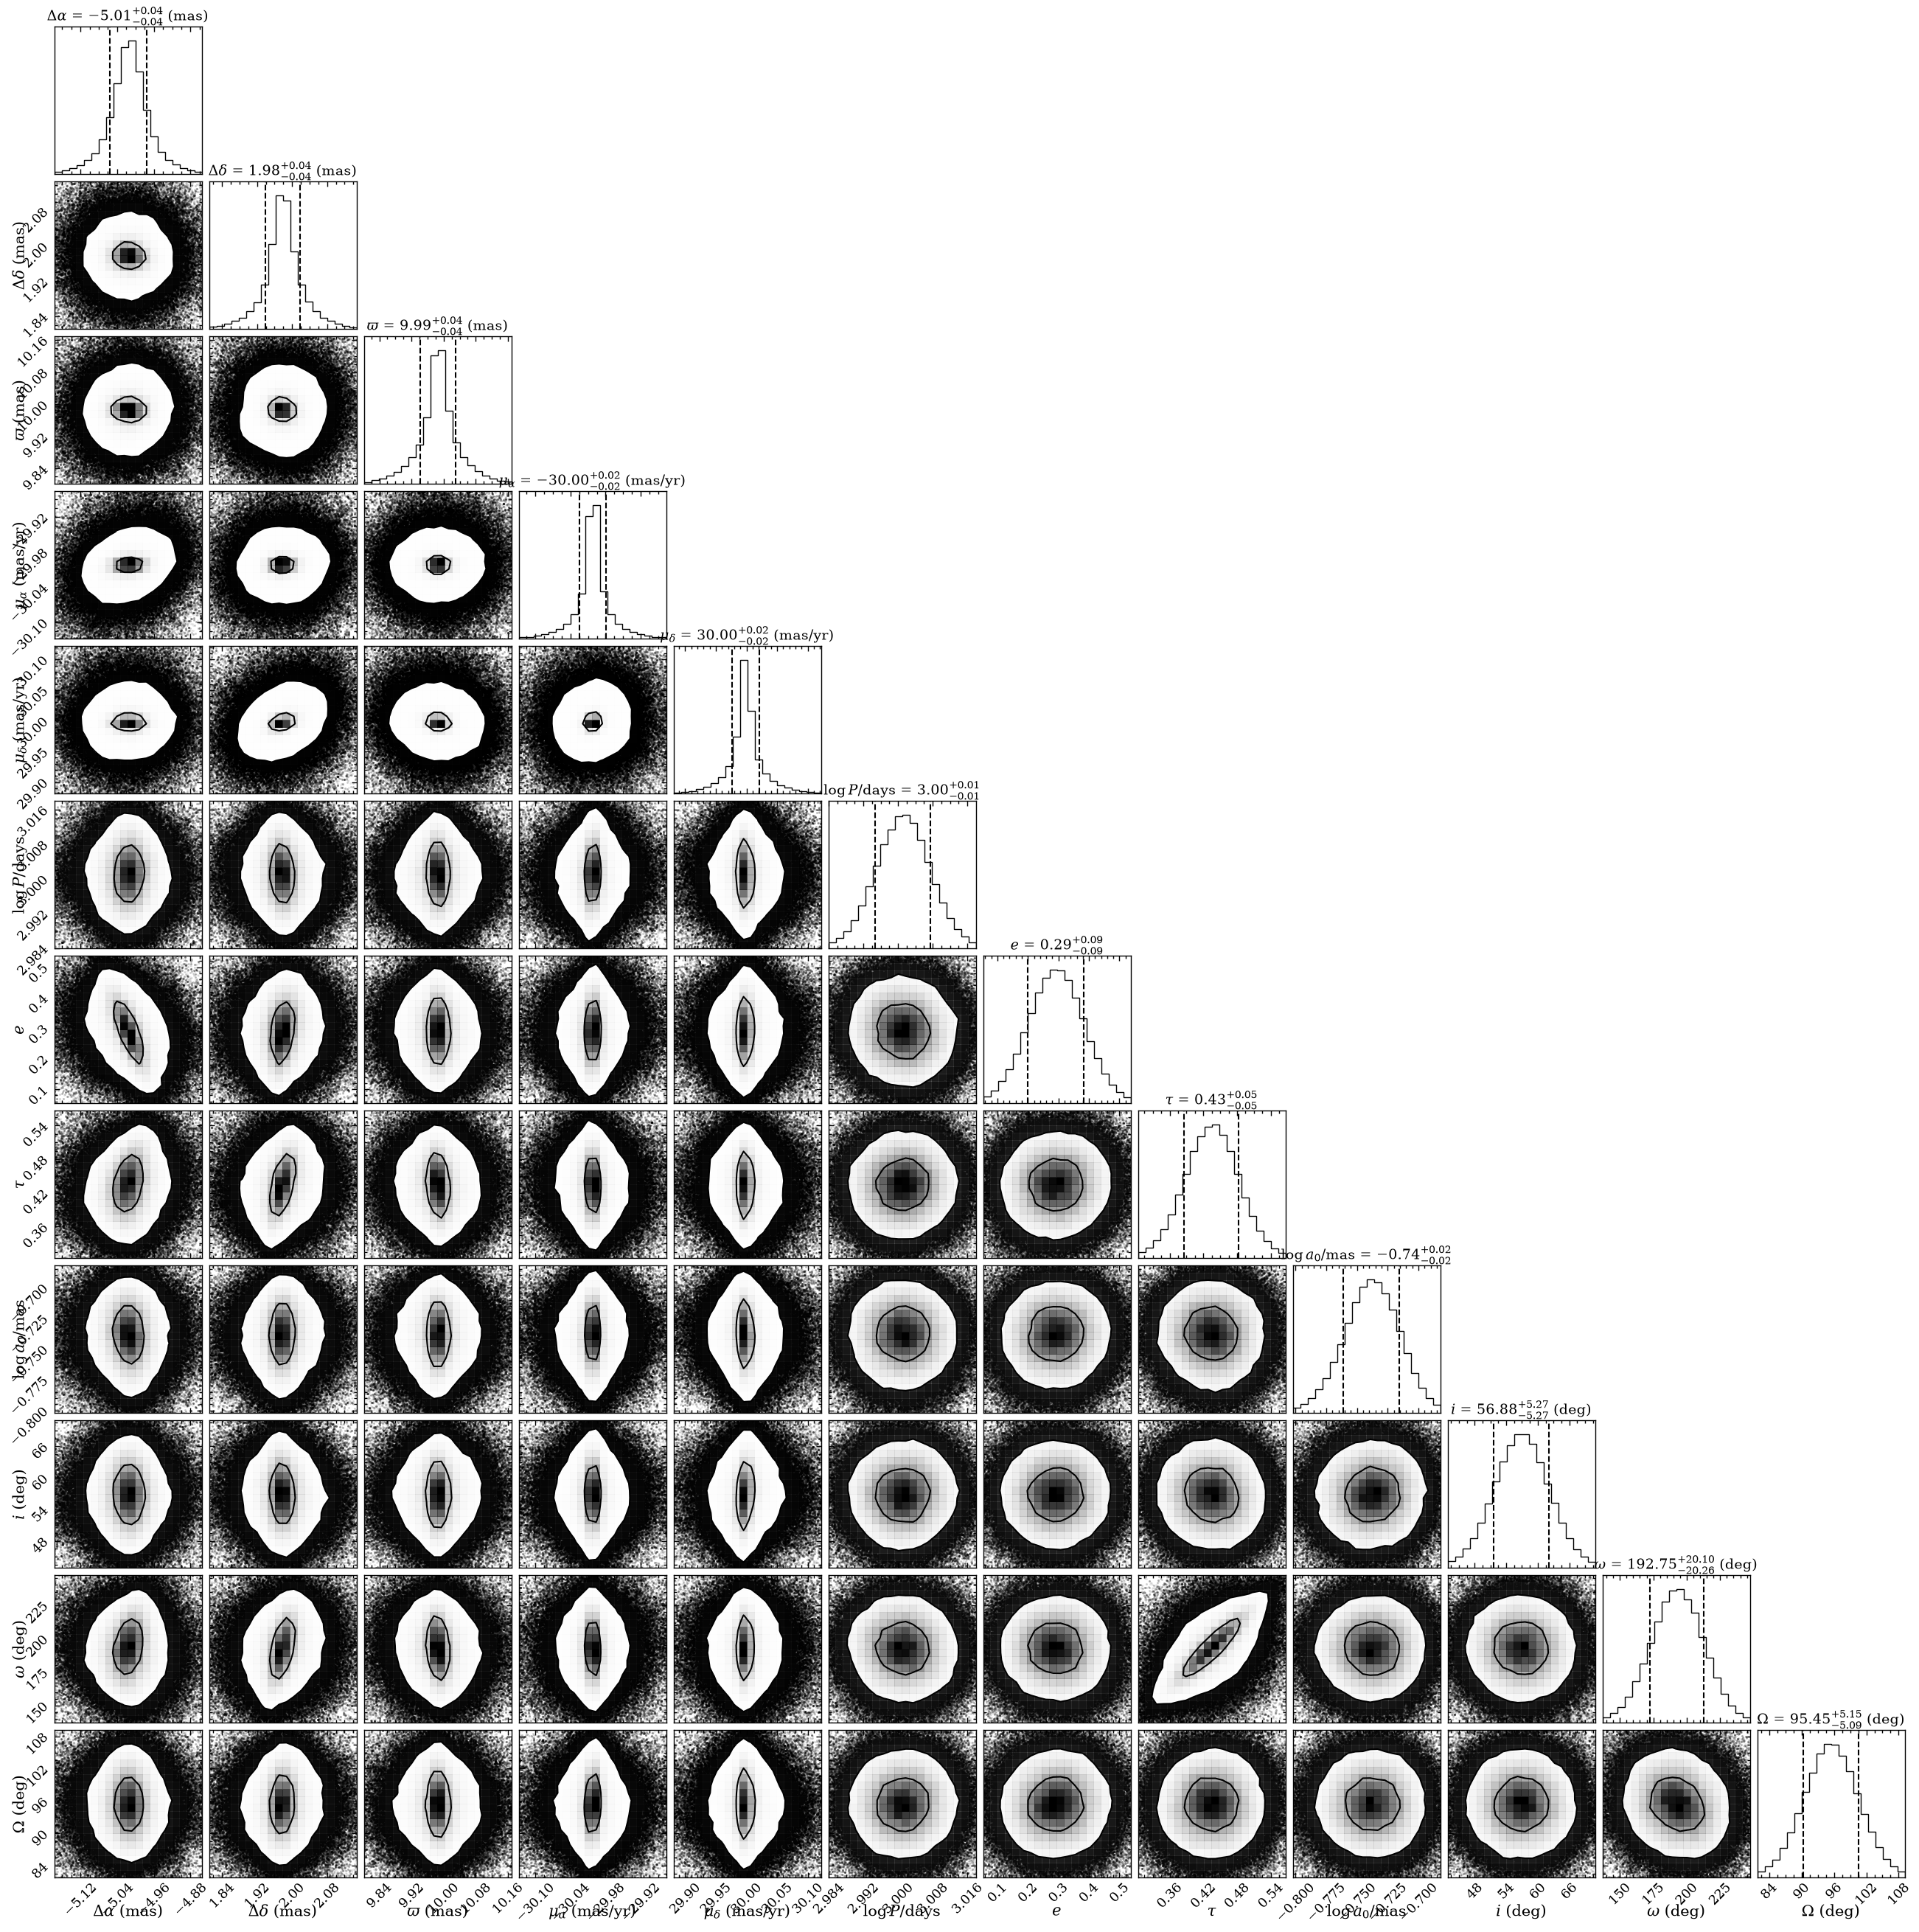

In [15]:
fig = results.plot_posterior(truths=None, plot_file='plot.png')


--------------
Plot residuals
--------------


Kepler model

Epoch astrometry: GaiaAstrometry

-----------------------
Calculate stellar track
-----------------------

Stellar parameters:
   - RA offset (mas) = -5.016
   - Dec offset (mas) = 1.982
   - Parallax (mas) = 9.984
   - Proper motion in RA (mas/yr) = -30.003
   - Proper motion in Dec (mas/yr) = 29.997

---------------------
Calculate orbit model
---------------------

Orbit parameters:
   - Period (days) = 1005.350
   - Eccentricity = 0.293
   - Relative time of periastron = 0.448
   - Semi-major axis (mas) = 0.182
   - Inclination (deg) = 55.460
   - Argument of periastron (deg) = 198.902
   - PA of ascending node (deg) = 94.467


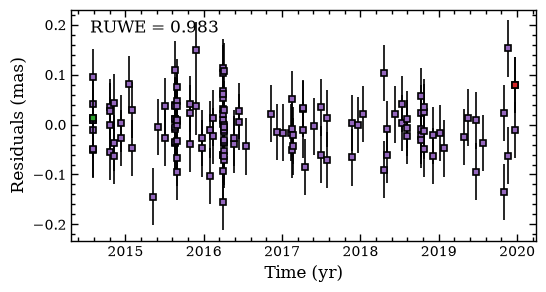

In [16]:
fig = results.plot_residuals(plot_file='plot.png')


----------
Plot orbit
----------



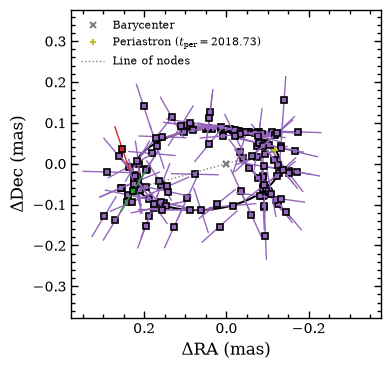

In [17]:
fig = results.plot_orbit(plot_file='plot.png')